# Set data directory

In [ ]:
path = './data'
path = '../publication/dltest/' ## THIS IS ONLY FOR TESTING

# Preamble

Install the necessary packages:

In [ ]:
%pip install tol-colors
%pip install aseMolec
%pip install ase
%pip install pandas
%pip install numpy
%pip install matplotlib

In [92]:
from ase.io import read, iread
import ase.units
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from aseMolec import pltProps as pp
from aseMolec import anaAtoms as aa
import pandas as pd
import numpy as np
import tol_colors as tc
cset = tc.tol_cset('bright')
plt.rc('axes', prop_cycle=plt.cycler('color', list(cset)))

small_pkl = './clusters-small_xyz.pkl'
medium_pkl = './clusters-medium_xyz.pkl'
large_pkl = './clusters-large_xyz.pkl'

scale = 2.5
fsize = 8*scale
plt.rcParams.update({'font.size': fsize})

In [67]:
def get_dynamic_data(data, handle=''):
    """Collect time (fs) and MSD (Å/fs) vectors.
    
    This function can be modified to treat any data based on the handle-variable.
    """
    if handle in ('B97D3', 'PBED3', 'PBED2', 'Clusters-Large', 'Clusters-Medium', 'Clusters-Small'):
        time = data['Time']['data']
        msd = data['MSD']['data']
        density = data['Density']['data']
    return time, msd, density


def get_trajectory_results(thermo, threshold=5e-2, window=2000, handle=None):
    results = {
        'Data set':[],
        'Labels':[],
        'Seed ID':[],
        'Sample ID':[],
        'Composition':[],
        'Temperature /K':[],
        'Density /g*cm-3':[],
        'Density std. /g*cm-3':[],
        'Diff. coeff. /1e6 cm2*s-1':[],
        'Diff. fit slope error /1e6 cm2*s-1':[],
        'Diff. fit R2':[],
        'Start time /ns':[],
        'Start time R2':[],
    }
    print(f'Using slope error thresold of: {threshold}, and moving window of: {window} frames')
    for i, tag in enumerate(thermo):
        print()
        print(tag)
        data_set, labels, seed, dset_sample = tag.split('/')
        seed_id = int(seed[-1])
        sample_id = int(dset_sample[-1])
        for j, (traj_name, traj_data) in enumerate(thermo[tag].items()):
            print(traj_name)
            ensemble, comp, temp = traj_name.split('_')
            temp = int(temp[:-1])
            
            # Collect data
            ## If loading data from sources with a different structure from this, this must be controlled using
            ## the handle-variable. In such case, get_dynamic_data must also be modified to accomodate this.
            if handle == 'Labels':
                time, msd, density = get_dynamic_data(traj_data, handle=labels)
            elif handle == 'Data set':
                time, msd, density = get_dynamic_data(traj_data, handle=data_set)

            # Obtain optimal starting time from unit log-log slope by fitting slopes in a moving window
            start_index, start_time_R2 = get_start_index(time, msd, threshold=threshold, window=window, start_id=0)

            if start_index != None:
                # Obtain diffusion coefficient with fitting errors
                diffusion_coeff, slope_error, diffusion_coeff_R2 = diffusion_coefficient(time[start_index:],msd[start_index:])
                print(f'start index: {start_index}, time steps: {len(time)}, start time R2: {start_time_R2:.5f}, Diff. coeff. (m^2/s): {diffusion_coeff:.5e}, slope error: {slope_error:.5e}, Diff. coeff. R2: {diffusion_coeff_R2:.5f}')
                
                results['Data set'].append(data_set)
                results['Labels'].append(label_map[labels])
                results['Seed ID'].append(seed_id)
                results['Sample ID'].append(sample_id)
                results['Composition'].append(comp_map[comp])
                results['Temperature /K'].append(temp)
                results['Density /g*cm-3'].append(np.mean(density))
                results['Density std. /g*cm-3'].append(np.std(density))
                results['Diff. coeff. /1e6 cm2*s-1'].append(diffusion_coeff*1e10)
                results['Diff. fit slope error /1e6 cm2*s-1'].append(slope_error*1e10)
                results['Diff. fit R2'].append(diffusion_coeff_R2)
                results['Start time /ns'].append(time[start_index]*1e-6)
                results['Start time R2'].append(start_time_R2)
            else:
                results['Data set'].append(np.nan)
                results['Labels'].append(np.nan)
                results['Seed ID'].append(np.nan)
                results['Sample ID'].append(np.nan)
                results['Composition'].append(np.nan)
                results['Temperature /K'].append(np.nan)
                results['Density /g*cm-3'].append(np.nan)
                results['Density std. /g*cm-3'].append(np.nan)
                results['Diff. coeff. /1e6 cm2*s-1'].append(np.nan)
                results['Diff. fit slope error /1e6 cm2*s-1'].append(np.nan)
                results['Diff. fit R2'].append(np.nan)
                results['Start time /ns'].append(np.nan)
                results['Start time R2'].append(np.nan)
    df = pd.DataFrame(results)
    return df


def get_xyz(tag, handle='xyz'):
    import glob
    flist = [name for name in glob.glob(tag)]
    for f in flist:
        if handle in f:
            print(f)
            return read(f, ':')


def RMSE(x,y):
    rmse = np.sqrt(np.mean((x-y)**2))
    rrmse = rmse/np.sqrt(np.mean((x-np.mean(x))**2))
    return rmse, rrmse


def get_all_thermo(tag, handle='.thermo'):
    """This needs to be exhanged for Ioans version in order to be consistent with
    zenodo.
    """
    import glob
    import os
    from aseMolec import pltProps as pp
    
    thermo = {}
    flist = [name for name in glob.glob(tag) if handle in name]
    for f in flist:
        print(f)
        aux = os.path.basename(f)
        key = os.path.splitext(aux)[0]
        if 'xyz' in handle:
            thermo.update({key: read(f, ':')})
        else:
            thermo.update({key: pp.loadtxttag(f)})
    return thermo


def diffusion_coefficient(time, msd):
    """Determines the diffusion coefficient in three dimensions
    from the slope of the MSD-curve.
    """
    from scipy.stats import linregress

    res = linregress(time,msd)
    diffusion_coeff = res.slope/6 #final unit: A^2/fs
    diffusion_coeff *= 1e-5 #final unit: m^2/s
    diffusion_err = res.stderr*1e-5 #final unit: m^2/s

    # Two-sided t-test for error in slope
    from scipy.stats import t
    tinv = lambda p, df: abs(t.ppf(p/2, df))
    ts = tinv(0.05, len(time)-2)
    return diffusion_coeff, ts*diffusion_err, res.rvalue**2


def get_slope(time, msd):
    from scipy.stats import linregress
    res = linregress(time,msd)
    return res.slope, res.intercept, res.stderr, res.rvalue**2


def get_start_index(time, msd, threshold, window, start_id=0):
    window = int(window)
    start_id = int(start_id)
    ids = {}
    for i, t in enumerate(time[start_id:]):
        if i > window:
            
            slope, intercept, err, r2 = get_slope(np.log(time[i:i+window]),np.log(msd[i:i+window]))
            if abs(slope-1) < threshold:
                ids[start_id+i] = r2
    idx, r2 = max(ids.items(), key=lambda x: x[1])
    return idx, r2


def rvalue_formatting(x):
    if x < 0.8:
        return 'background-color: red'
    elif x < 0.9:
        return 'background-color: orange'
    elif x < 0.95:
        return 'background-color: yellow'
    else:
        return None

def rvalue_formatting_latex(x, trunc=6):
    if x < 0.8:
        return r'\color{RED}'+str(x)[:trunc]
    elif x < 0.9:
        return r'\color{ORANGE}'+str(x)[:trunc]
    elif x < 0.95:
        return r'\color{YELLOW}'+str(x)[:trunc]
    else:
        return str(x)[:trunc]

def get_colour(name):
    colmap = {
        'EMC':'blue',
        'EC:EMC (3:7)':'green',
        'EC:EMC (7:3)':'yellow',
        'EC':'red',
    }
    return getattr(cset, colmap[name])


def get_mol_positions(atoms):
	positions = []
	mol_set = set(atoms.arrays['molID'])
	for ID in mol_set:
		mol = atoms[atoms.arrays['molID'] == ID]
		com = mol.get_center_of_mass()
		positions.append(com)
	positions = np.array(positions)
	return positions


def mol_rdf(atoms, rmax, nbins, return_num_mols=False):
	positions = get_mol_positions(atoms)
	nmols, dim = positions.shape
	box_length = atoms.get_volume()**(1/3)
	for i, p in enumerate(positions):
		# PBC
		delta = positions[i+1:]-positions[i]
		delta -= box_length*np.round(delta/box_length)
		
		# Get counts
		dists = np.linalg.norm(delta, axis=1)
		s = sorted(dists[dists <= rmax])[1:]
		if i == 0:
			counts, bins = np.histogram(s, nbins, (0,rmax))
		else:
			counts += np.histogram(s, nbins, (0,rmax))[0]

	if return_num_mols:
		return counts, bins, nmols
	else:
		return counts, bins
     

def compute_mol_rdf(traj, rmax=None, nbins=100, return_rho=False):
	for i, atoms in enumerate(traj):
		if i == 0:
			counts, bins, nmols = mol_rdf(atoms, rmax=rmax, nbins=nbins, return_num_mols=True)
			volume = atoms.get_volume()
			box_length = volume**(1/3)
			r = 0.5*(bins[1:]+bins[:-1])
		else:
			counts += mol_rdf(atoms, rmax=rmax, nbins=nbins)[0]
	
	num_snapshots = i+1
	nvalid = nmols/2
	n_k = counts/(nvalid*num_snapshots)	
	dr = rmax/nbins
	shell_volumes = 4/3*np.pi*((r+dr)**3-r**3)
	rho = nmols/volume
	
	g = n_k/(rho*shell_volumes)
	if return_rho:
		return g, r, rho
	else:
		return g, r


def get_mol_rdfs(path, tags, slice=':'):
    import glob
    from aseMolec import anaAtoms as aa

    rdfs = {}
    number_densities = {}
    for tag in tags:
        data_set, labels, seed, dset_sample = tag.split('/')
        flist = [name for name in glob.glob(f'{path}{tag}/dynamics/*') if '.xyz' in name]
        name = f'{data_set}_{labels}'
        print(name, dset_sample, seed)

        for file in flist:
            print(file)
            comp = file.split('/')[-1].split('.')[0][4:-5]
            comp = comp_map[comp]
            traj = read(file, slice)
            aa.find_molecs(traj, fct=1.0)
            g, r, rho = compute_mol_rdf(traj, rmax=11, return_rho=True)

            if name not in rdfs:
                rdfs[name] = {}
            if dset_sample not in rdfs[name]:
                rdfs[name][dset_sample] = {}
            if seed not in rdfs[name][dset_sample]:
                rdfs[name][dset_sample][seed] = {}
            
            if name not in number_densities:
                number_densities[name] = {}
            if dset_sample not in number_densities[name]:
                number_densities[name][dset_sample] = {}
            if seed not in number_densities[name][dset_sample]:
                number_densities[name][dset_sample][seed] = {}

            rdfs[name][dset_sample][seed][comp] = [g, r]
            number_densities[name][dset_sample][seed][comp] = rho
            del traj
    
    return rdfs, number_densities

def get_indices_of_sign_change(lst):
    arr = np.array(lst)
    sign_changes = np.where(np.diff(np.sign(arr)) != 0)[0]
    return sign_changes


def yaml_to_multidf(fname, index_list):
    import yaml
    import pandas as pd
    
    # Load YAML
    with open(fname, "r") as f:
        raw = yaml.safe_load(f)
    f.close()

    # Convert to DataFrame
    df = pd.DataFrame(raw['metadata'])

    # Set MultiIndex
    df = df.set_index(index_list)
    return df


def download_file(url, output_file):
	import requests
	from pathlib import Path
	print(f"Downloading {url} -> {output_file}")
	response = requests.get(url)
	response.raise_for_status()

	Path(output_file).parent.mkdir(parents=True, exist_ok=True)

	with open(output_file, "wb") as f:
		f.write(response.content)


def unzip_file(zip_path, extract_to):
	from pathlib import Path
	import zipfile
	print(zip_path)
	print(f"Unzipping {zip_path} -> {extract_to}")
	Path(extract_to).mkdir(parents=True, exist_ok=True)

	with zipfile.ZipFile(zip_path, "r") as z:
		z.extractall(extract_to)


def download_unpack(root, config_path, key):
	import yaml; import os.path
	with open(root+config_path, "r") as f:
		config = yaml.safe_load(f)

	for item in config[key]:
		url = item["url"]
		output_file = item["output_file"]
		extract_to = item["extract_to"]

		if not os.path.isfile(root+output_file):
			download_file(url, root+output_file)
		unzip_file(root+output_file, root+extract_to)


In [68]:
def get_dynamic_data(data, handle=''):
    """Collect time (fs) and MSD (Å/fs) vectors.
    
    This function can be modified to treat any data based on the handle-variable.
    """
    if handle in ('B97D3', 'PBED3', 'PBED2', 'Clusters-Large', 'Clusters-Medium', 'Clusters-Small'):
        time = data['Time']['data']
        msd = data['MSD']['data']
        density = data['Density']['data']
    return time, msd, density


def get_trajectory_results(thermo, threshold=5e-2, window=2000, handle=None):
    results = {
        'Data set':[],
        'Labels':[],
        'Seed ID':[],
        'Sample ID':[],
        'Composition':[],
        'Temperature /K':[],
        'Density /g*cm-3':[],
        'Density std. /g*cm-3':[],
        'Diff. coeff. /1e6 cm2*s-1':[],
        'Diff. fit slope error /1e6 cm2*s-1':[],
        'Diff. fit R2':[],
        'Start time /ns':[],
        'Start time R2':[],
    }
    print(f'Using slope error thresold of: {threshold}, and moving window of: {window} frames')
    for i, tag in enumerate(thermo):
        print()
        print(tag)
        data_set, labels, seed, dset_sample = tag.split('/')
        seed_id = int(seed[-1])
        sample_id = int(dset_sample[-1])
        for j, (traj_name, traj_data) in enumerate(thermo[tag].items()):
            print(traj_name)
            ensemble, comp, temp = traj_name.split('_')
            temp = int(temp[:-1])
            
            # Collect data
            ## If loading data from sources with a different structure from this, this must be controlled using
            ## the handle-variable. In such case, get_dynamic_data must also be modified to accomodate this.
            if handle == 'Labels':
                time, msd, density = get_dynamic_data(traj_data, handle=labels)
            elif handle == 'Data set':
                time, msd, density = get_dynamic_data(traj_data, handle=data_set)

            # Obtain optimal starting time from unit log-log slope by fitting slopes in a moving window
            start_index, start_time_R2 = get_start_index(time, msd, threshold=threshold, window=window, start_id=0)

            if start_index != None:
                # Obtain diffusion coefficient with fitting errors
                diffusion_coeff, slope_error, diffusion_coeff_R2 = diffusion_coefficient(time[start_index:],msd[start_index:])
                print(f'start index: {start_index}, time steps: {len(time)}, start time R2: {start_time_R2:.5f}, Diff. coeff. (m^2/s): {diffusion_coeff:.5e}, slope error: {slope_error:.5e}, Diff. coeff. R2: {diffusion_coeff_R2:.5f}')
                
                results['Data set'].append(data_set)
                results['Labels'].append(label_map[labels])
                results['Seed ID'].append(seed_id)
                results['Sample ID'].append(sample_id)
                results['Composition'].append(comp_map[comp])
                results['Temperature /K'].append(temp)
                results['Density /g*cm-3'].append(np.mean(density))
                results['Density std. /g*cm-3'].append(np.std(density))
                results['Diff. coeff. /1e6 cm2*s-1'].append(diffusion_coeff*1e10)
                results['Diff. fit slope error /1e6 cm2*s-1'].append(slope_error*1e10)
                results['Diff. fit R2'].append(diffusion_coeff_R2)
                results['Start time /ns'].append(time[start_index]*1e-6)
                results['Start time R2'].append(start_time_R2)
            else:
                results['Data set'].append(np.nan)
                results['Labels'].append(np.nan)
                results['Seed ID'].append(np.nan)
                results['Sample ID'].append(np.nan)
                results['Composition'].append(np.nan)
                results['Temperature /K'].append(np.nan)
                results['Density /g*cm-3'].append(np.nan)
                results['Density std. /g*cm-3'].append(np.nan)
                results['Diff. coeff. /1e6 cm2*s-1'].append(np.nan)
                results['Diff. fit slope error /1e6 cm2*s-1'].append(np.nan)
                results['Diff. fit R2'].append(np.nan)
                results['Start time /ns'].append(np.nan)
                results['Start time R2'].append(np.nan)
    df = pd.DataFrame(results)
    return df


def get_xyz(tag, handle='xyz'):
    import glob
    flist = [name for name in glob.glob(tag)]
    for f in flist:
        if handle in f:
            print(f)
            return read(f, ':')


def RMSE(x,y):
    rmse = np.sqrt(np.mean((x-y)**2))
    rrmse = rmse/np.sqrt(np.mean((x-np.mean(x))**2))
    return rmse, rrmse


def get_all_thermo(tag, handle='.thermo'):
    """This needs to be exhanged for Ioans version in order to be consistent with
    zenodo.
    """
    import glob
    import os
    from aseMolec import pltProps as pp
    
    thermo = {}
    flist = [name for name in glob.glob(tag) if handle in name]
    for f in flist:
        print(f)
        aux = os.path.basename(f)
        key = os.path.splitext(aux)[0]
        if 'xyz' in handle:
            thermo.update({key: read(f, ':')})
        else:
            thermo.update({key: pp.loadtxttag(f)})
    return thermo


def diffusion_coefficient(time, msd):
    """Determines the diffusion coefficient in three dimensions
    from the slope of the MSD-curve.
    """
    from scipy.stats import linregress

    res = linregress(time,msd)
    diffusion_coeff = res.slope/6 #final unit: A^2/fs
    diffusion_coeff *= 1e-5 #final unit: m^2/s
    diffusion_err = res.stderr*1e-5 #final unit: m^2/s

    # Two-sided t-test for error in slope
    from scipy.stats import t
    tinv = lambda p, df: abs(t.ppf(p/2, df))
    ts = tinv(0.05, len(time)-2)
    return diffusion_coeff, ts*diffusion_err, res.rvalue**2


def get_slope(time, msd):
    from scipy.stats import linregress
    res = linregress(time,msd)
    return res.slope, res.intercept, res.stderr, res.rvalue**2


def get_start_index(time, msd, threshold, window, start_id=0):
    window = int(window)
    start_id = int(start_id)
    ids = {}
    for i, t in enumerate(time[start_id:]):
        if i > window:
            
            slope, intercept, err, r2 = get_slope(np.log(time[i:i+window]),np.log(msd[i:i+window]))
            if abs(slope-1) < threshold:
                ids[start_id+i] = r2
    idx, r2 = max(ids.items(), key=lambda x: x[1])
    return idx, r2


def rvalue_formatting(x):
    if x < 0.8:
        return 'background-color: red'
    elif x < 0.9:
        return 'background-color: orange'
    elif x < 0.95:
        return 'background-color: yellow'
    else:
        return None

def rvalue_formatting_latex(x, trunc=6):
    if x < 0.8:
        return r'\color{RED}'+str(x)[:trunc]
    elif x < 0.9:
        return r'\color{ORANGE}'+str(x)[:trunc]
    elif x < 0.95:
        return r'\color{YELLOW}'+str(x)[:trunc]
    else:
        return str(x)[:trunc]

def get_colour(name):
    colmap = {
        'EMC':'blue',
        'EC:EMC (3:7)':'green',
        'EC:EMC (7:3)':'yellow',
        'EC':'red',
    }
    return getattr(cset, colmap[name])


def get_mol_positions(atoms):
	positions = []
	mol_set = set(atoms.arrays['molID'])
	for ID in mol_set:
		mol = atoms[atoms.arrays['molID'] == ID]
		com = mol.get_center_of_mass()
		positions.append(com)
	positions = np.array(positions)
	return positions


def mol_rdf(atoms, rmax, nbins, return_num_mols=False):
	positions = get_mol_positions(atoms)
	nmols, dim = positions.shape
	box_length = atoms.get_volume()**(1/3)
	for i, p in enumerate(positions):
		# PBC
		delta = positions[i+1:]-positions[i]
		delta -= box_length*np.round(delta/box_length)
		
		# Get counts
		dists = np.linalg.norm(delta, axis=1)
		s = sorted(dists[dists <= rmax])[1:]
		if i == 0:
			counts, bins = np.histogram(s, nbins, (0,rmax))
		else:
			counts += np.histogram(s, nbins, (0,rmax))[0]

	if return_num_mols:
		return counts, bins, nmols
	else:
		return counts, bins
     

def compute_mol_rdf(traj, rmax=None, nbins=100, return_rho=False):
	for i, atoms in enumerate(traj):
		if i == 0:
			counts, bins, nmols = mol_rdf(atoms, rmax=rmax, nbins=nbins, return_num_mols=True)
			volume = atoms.get_volume()
			box_length = volume**(1/3)
			r = 0.5*(bins[1:]+bins[:-1])
		else:
			counts += mol_rdf(atoms, rmax=rmax, nbins=nbins)[0]
	
	num_snapshots = i+1
	nvalid = nmols/2
	n_k = counts/(nvalid*num_snapshots)	
	dr = rmax/nbins
	shell_volumes = 4/3*np.pi*((r+dr)**3-r**3)
	rho = nmols/volume
	
	g = n_k/(rho*shell_volumes)
	if return_rho:
		return g, r, rho
	else:
		return g, r


def get_mol_rdfs(path, tags, slice=':'):
    import glob
    from aseMolec import anaAtoms as aa

    rdfs = {}
    number_densities = {}
    for tag in tags:
        data_set, labels, seed, dset_sample = tag.split('/')
        flist = [name for name in glob.glob(f'{path}{tag}/dynamics/*') if '.xyz' in name]
        name = f'{data_set}_{labels}'
        print(name, dset_sample, seed)

        for file in flist:
            print(file)
            comp = file.split('/')[-1].split('.')[0][4:-5]
            comp = comp_map[comp]
            traj = read(file, slice)
            aa.find_molecs(traj, fct=1.0)
            g, r, rho = compute_mol_rdf(traj, rmax=11, return_rho=True)

            if name not in rdfs:
                rdfs[name] = {}
            if dset_sample not in rdfs[name]:
                rdfs[name][dset_sample] = {}
            if seed not in rdfs[name][dset_sample]:
                rdfs[name][dset_sample][seed] = {}
            
            if name not in number_densities:
                number_densities[name] = {}
            if dset_sample not in number_densities[name]:
                number_densities[name][dset_sample] = {}
            if seed not in number_densities[name][dset_sample]:
                number_densities[name][dset_sample][seed] = {}

            rdfs[name][dset_sample][seed][comp] = [g, r]
            number_densities[name][dset_sample][seed][comp] = rho
            del traj
    
    return rdfs, number_densities

def get_indices_of_sign_change(lst):
    arr = np.array(lst)
    sign_changes = np.where(np.diff(np.sign(arr)) != 0)[0]
    return sign_changes








def yaml_to_multidf(fname, index_list):
    import yaml
    import pandas as pd
    
    # Load YAML
    with open(fname, "r") as f:
        raw = yaml.safe_load(f)
    f.close()

    # Convert to DataFrame
    df = pd.DataFrame(raw['metadata'])

    # Set MultiIndex
    df = df.set_index(index_list)
    return df


def download_file(url, output_file):
	import requests
	from pathlib import Path
	print(f"Downloading {url} -> {output_file}")
	response = requests.get(url)
	response.raise_for_status()

	Path(output_file).parent.mkdir(parents=True, exist_ok=True)

	with open(output_file, "wb") as f:
		f.write(response.content)


def unzip_file(zip_path, extract_to):
	from pathlib import Path
	import zipfile
	print(zip_path)
	print(f"Unzipping {zip_path} -> {extract_to}")
	Path(extract_to).mkdir(parents=True, exist_ok=True)

	with zipfile.ZipFile(zip_path, "r") as z:
		z.extractall(extract_to)


def download_unpack(root, config_path, key):
	import yaml; import os.path
	with open(root+config_path, "r") as f:
		config = yaml.safe_load(f)

	for item in config[key]:
		url = item["url"]
		output_file = item["output_file"]
		extract_to = item["extract_to"]

		if not os.path.isfile(root+output_file):
			download_file(url, root+output_file)
		unzip_file(root+output_file, root+extract_to)


def flatten_results(df, prop_handle, merge_type):
    if merge_type == 'mean':
        return df[prop_handle].mean()
    elif merge_type == 'std':
        return df[prop_handle].std()


def get_committee_results(df, group_by, droplist):
    dfs = []
    for group_name, group in df.groupby(group_by):
        tmp = []
        for comp_name, comp in group.groupby('Composition'):
            t = comp.iloc[0].copy()
            t['Density /g*cm-3'] = flatten_results(comp, 'Density /g*cm-3', merge_type='mean')
            t['Density std. /g*cm-3'] = flatten_results(comp, 'Density /g*cm-3', merge_type='std')
            t['Diff. coeff. /1e6 cm2*s-1'] = flatten_results(comp, 'Diff. coeff. /1e6 cm2*s-1', merge_type='mean')
            t['Diff. fit slope error /1e6 cm2*s-1'] = flatten_results(comp, 'Diff. coeff. /1e6 cm2*s-1', merge_type='std')
            t = t.drop(droplist)
            tmp.append(t)
        dfs.append(pd.DataFrame(tmp)) 
    return pd.concat(dfs)



In [69]:
def collect_comp(db):
    from collections import Counter
    buf = {}
    for at in db:
        if at.info['Nmols'] in buf:
            try:
                buf[at.info['Nmols']] += [at.info['Comp']]
            except:
                buf[at.info['Nmols']] += [at.info['config_type']]
        else:
            try:
                buf[at.info['Nmols']] = [at.info['Comp']]
            except:
                buf[at.info['Nmols']] = [at.info['config_type']]

    comp = {}
    for b in buf:
        comp[b] = dict(Counter(buf[b]))
    return comp


def flatten_comp(comp_dict):
    flattened_comp_dict = {}
    for csize, dist in comp_dict.items():
        tmp = {
            'EMC':0,
            'EC':0,
            'EC and EMC + other':0,
            'EC or EMC + other':0,
            'Other':0,
        }
        for comp, count in dist.items():
            part = comp.split(':')
            part = [p.split('(')[0] for p in part]
            part = [''.join([i for i in p if not i.isdigit()]) for p in part]
            if ('EC' not in part) and ('EMC' not in part):
                tmp['Other'] += count            
            elif ('EC' in part) and ('EMC' in part):
                tmp['EC and EMC + other'] += count
            elif ('EC' in part) and ('EMC' not in part):
                if len(set(part)) == 1:
                    tmp['EC'] += count
                else:
                    tmp['EC or EMC + other'] += count
            elif ('EC' not in part) and ('EMC' in part):
                if len(set(part)) == 1:
                    tmp['EMC'] += count
                else:
                    tmp['EC or EMC + other'] += count
            else:
                tmp['EC or EMC + other'] += count

        flattened_comp_dict[csize] = tmp
    df = pd.DataFrame(flattened_comp_dict).T
    return df.sort_index(inplace=False)


def get_mol_histograms(xyz_dict):
    histogram_dict = {
        key:np.histogram(np.array([a.info['Nmols'] for a in xyz]), [1,2,3,4,5,6,7])[0]
        for key, xyz in xyz_dict.items()
    }
    return histogram_dict


def hist_dict_to_df(hist_dict):
    hist_df = pd.DataFrame(hist_dict)
    hist_df.index.name = 'Cluster size, Nmols'
    hist_df.index += 1
    return hist_df


def get_expectation_values(hist_df, arr):
    column_totals = hist_df.aggregate('sum', axis=0)
    prob_df = hist_df/column_totals
    expectation = (prob_df*arr[:,None]).aggregate('sum', axis=0).round(decimals=2)
    return expectation

# Download
## MLIP data
MLIP data refers to training data, trained MLIPs and associated files.

In [ ]:
download_unpack(path, "clusters_metadata.yaml", "MLIP downloads")

## Data overview

In [73]:
meta_df = yaml_to_multidf(path+"clusters_metadata.yaml", ["Labels", "Parent data", "Data set"])
meta_df

Subset  Seeds  Number of structures  \
Labels   Parent data     Data set                                               
wB97X-D3 Clusters-Full   Clusters-Large        1      3                221824   
         Clusters-Large  Clusters-Medium       1      3                 42824   
                         Clusters-Medium       2      1                 42824   
                         Clusters-Medium       3      1                 42824   
         Clusters-Medium Clusters-Small        1      3                  8016   
                         Clusters-Small        2      1                  8016   
                         Clusters-Small        3      1                  8016   
B97-D3   Clusters-Large  Clusters-Medium       1      1                 42824   
                         Clusters-Medium       2      1                 42824   
                         Clusters-Medium       3      1                 42824   
         Clusters-Medium Clusters-Small        1      1                  8016   
                         Clusters-Small        2      1                  8016   
                         Clusters-Small        3      1                  8016   

                                          Number of atoms  
Labels   Parent data     Data set                          
wB97X-D3 Clusters-Full   Clusters-Large           4805916  
         Clusters-Large  Clusters-Medium          1269916  
                         Clusters-Medium          1269916  
                         Clusters-Medium          1269916  
         Clusters-Medium Clusters-Small            327089  
                         Clusters-Small            327089  
                         Clusters-Small            327089  
B97-D3   Clusters-Large  Clusters-Medium          1269916  
                         Clusters-Medium          1269916  
                         Clusters-Medium          1269916  
         Clusters-Medium Clusters-Small            327089  
                         Clusters-Small            327089  
                         Clusters-Small            327089

# Dataset statistics

## Small clusters dataset
Store xyz-data in a pickle file for faster access (may take a while to run):

In [ ]:
import pickle
from ase.io import read
from pathlib import Path

if not Path(small_pkl).exists():
    clusters_small_1 = read(f'{path}Clusters-Small/wB97XD3/SEED1/DSET1/training/SD22NQQ1_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms
    clusters_small_2 = read(f'{path}Clusters-Small/wB97XD3/SEED1/DSET2/training/SD22NQQ2_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms
    clusters_small_3 = read(f'{path}Clusters-Small/wB97XD3/SEED1/DSET3/training/SD22NQQ3_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms

    xyz_dict = {'Clusters-Small-1':clusters_small_1, 'Clusters-Small-2':clusters_small_2, 'Clusters-Small-3':clusters_small_3}
    with open(small_pkl, 'wb') as f:
        pickle.dump(xyz_dict, f)

    num_atoms_small = sum([len(a.numbers) for a in clusters_small_1])

### Cluster composition
Read pickled data:

In [75]:
import pickle

with open(small_pkl, 'rb') as f:
    clusters_small_dict = pickle.load(f)

Cluster distributions:

In [ ]:
clusters_small_histograms = get_mol_histograms(clusters_small_dict)
clusters_small_df = hist_dict_to_df(clusters_small_histograms)

Show output:

In [ ]:
hist_df = clusters_small_df.copy()
hist_df.loc['Total']= hist_df.sum()
hist_df

,Clusters-Small-1,Clusters-Small-2,Clusters-Small-3
"Cluster size, Nmols",,,
1,900,900,900
2,1470,1470,1470
3,2001,2001,2001
4,1917,1917,1917
5,1464,1464,1464
6,264,264,264
Total,8016,8016,8016


### Molecular composition
Molecular dustribution:

In [80]:
data = 'Clusters-Small-1'
print(f'{data}:')
comp = collect_comp(clusters_small_dict[data])
clusters_small_1_comp = flatten_comp(comp)
clusters_small_1_comp

Clusters-Small-1:


,EMC,EC,EC and EMC + other,EC or EMC + other,Other
1,150,150,0,0,600
2,70,70,70,560,700
3,40,40,220,1073,628
4,41,200,189,706,781
5,25,322,139,344,634
6,0,0,144,110,10


In [81]:
data = 'Clusters-Small-2'
print(f'{data}:')
comp = collect_comp(clusters_small_dict[data])
clusters_small_2_comp = flatten_comp(comp)
clusters_small_2_comp

Clusters-Small-2:


,EMC,EC,EC and EMC + other,EC or EMC + other,Other
1,150,150,0,0,600
2,70,70,70,560,700
3,40,40,220,1073,628
4,41,200,189,706,781
5,25,322,139,344,634
6,0,0,144,110,10


In [82]:
data = 'Clusters-Small-3'
print(f'{data}:')
comp = collect_comp(clusters_small_dict[data])
clusters_small_3_comp = flatten_comp(comp)
clusters_small_3_comp

Clusters-Small-3:


,EMC,EC,EC and EMC + other,EC or EMC + other,Other
1,150,150,0,0,600
2,70,70,70,560,700
3,40,40,220,1073,628
4,41,200,189,706,781
5,25,322,139,344,634
6,0,0,144,110,10


## Medium clusters dataset
Store xyz-data in a pickle file for faster access (may take a while to run):

In [ ]:
import pickle
from ase.io import read
from pathlib import Path

if not Path(medium_pkl).exists():
    clusters_medium_1 = read(f'{path}Clusters-Medium/wB97XD3/SEED1/DSET1/training/SD22NQ1_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms
    clusters_medium_2 = read(f'{path}Clusters-Medium/wB97XD3/SEED1/DSET2/training/SD22NQ2_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms
    clusters_medium_3 = read(f'{path}Clusters-Medium/wB97XD3/SEED1/DSET3/training/SD22NQ3_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms

    xyz_dict = {'Clusters-Medium-1':clusters_medium_1, 'Clusters-Medium-2':clusters_medium_2, 'Clusters-Medium-3':clusters_medium_3}
    with open(medium_pkl, 'wb') as f:
        pickle.dump(xyz_dict, f)

    num_atoms_medium = sum([len(a.numbers) for a in clusters_medium_1])

### Cluster composition
Read pickled data:

In [74]:
import pickle

with open(medium_pkl, 'rb') as f:
    clusters_medium_dict = pickle.load(f)

Cluster distribtution:

In [ ]:
clusters_medium_histograms = get_mol_histograms(clusters_medium_dict)
clusters_medium_df = hist_dict_to_df(clusters_medium_histograms)

Show output:

In [ ]:
hist_df = clusters_medium_df.copy()
hist_df.loc['Total']= hist_df.sum()
hist_df

,Clusters-Medium-1,Clusters-Medium-2,Clusters-Medium-3
"Cluster size, Nmols",,,
1,7878,7880,7880
2,18252,18253,18253
3,10176,10176,10176
4,4787,4787,4787
5,1464,1464,1464
6,264,264,264
Total,42821,42824,42824


### Molecular composition
Molecular dustribution:

In [76]:
data = 'Clusters-Medium-1'
print(f'{data}:')
comp = collect_comp(clusters_medium_dict[data])
clusters_medium_1_comp = flatten_comp(comp)
clusters_medium_1_comp

Clusters-Medium-1:


,EMC,EC,EC and EMC + other,EC or EMC + other,Other
1,886,2354,0,0,4638
2,1069,190,1092,9087,6814
3,178,1091,516,2433,5958
4,41,1528,189,706,2323
5,25,322,139,344,634
6,0,0,144,110,10


In [77]:
data = 'Clusters-Medium-2'
print(f'{data}:')
comp = collect_comp(clusters_medium_dict[data])
clusters_medium_2_comp = flatten_comp(comp)
clusters_medium_2_comp

Clusters-Medium-2:


,EMC,EC,EC and EMC + other,EC or EMC + other,Other
1,887,2354,0,0,4639
2,1069,190,1092,9088,6814
3,178,1091,516,2433,5958
4,41,1528,189,706,2323
5,25,322,139,344,634
6,0,0,144,110,10


In [78]:
data = 'Clusters-Medium-3'
print(f'{data}:')
comp = collect_comp(clusters_medium_dict[data])
clusters_medium_3_comp = flatten_comp(comp)
clusters_medium_3_comp

Clusters-Medium-3:


,EMC,EC,EC and EMC + other,EC or EMC + other,Other
1,887,2354,0,0,4639
2,1069,190,1092,9088,6814
3,178,1091,516,2433,5958
4,41,1528,189,706,2323
5,25,322,139,344,634
6,0,0,144,110,10


## Large clusters dataset
Store xyz-data in a pickle file for faster access (may take a while to run):

In [79]:
import pickle
from ase.io import read
from pathlib import Path

if not Path(large_pkl).exists():
    clusters_large = read(f'{path}Clusters-Large/wB97XD3/SEED1/DSET1/training/SD22N_wB97XD3BJ_Psi4.xyz', '3:') # first three structures are single atoms

    xyz_dict = {'Clusters-Large':clusters_large}
    with open(large_pkl, 'wb') as f:
        pickle.dump(xyz_dict, f)

    num_atoms_large = sum([len(a.numbers) for a in clusters_large])

### Cluster composition
Read pickled data:

In [ ]:
import pickle

with open(large_pkl, 'rb') as f:
    clusters_large_dict = pickle.load(f)

Cluster distributions:

In [ ]:
clusters_large_histograms = get_mol_histograms(clusters_large_dict)
clusters_large_df = hist_dict_to_df(clusters_large_histograms)

Show output:

In [ ]:
hist_df = clusters_large_df.copy()
hist_df.loc['Total']= hist_df.sum()
hist_df

,Clusters-Large
"Cluster size, Nmols",
1,77878
2,82252
3,37176
4,17787
5,6464
6,264
Total,221821


### Molecular composition
Molecular dustribution:

In [83]:
data = 'Clusters-Large'
print(f'{data}:')
comp = collect_comp(clusters_large_dict[data])
clusters_large_comp = flatten_comp(comp)
clusters_large_comp

Clusters-Large:


,EMC,EC,EC and EMC + other,EC or EMC + other,Other
1,887,72353,0,0,4638
2,1069,40189,1092,9088,30814
3,178,23091,516,2433,10958
4,41,11528,189,706,5323
5,25,5322,139,344,634
6,0,0,144,110,10


## Overall statistics

### Expected cluster sizes

In [53]:
dfs = {
    'Clusters-Small':clusters_small_df['Clusters-Small-1'],
    'Clusters-Medium':clusters_medium_df['Clusters-Medium-1'],
    'Clusters-Large':clusters_large_df['Clusters-Large'],
}
stats_df = pd.concat(dfs.values(), axis=1, keys=dfs.keys())
expectation = get_expectation_values(stats_df, stats_df.index.to_numpy())
variance = get_expectation_values(stats_df, stats_df.index.to_numpy()**2) - expectation**2
stats_df

,Clusters-Small,Clusters-Medium,Clusters-Large
"Cluster size, Nmols",,,
1,900,7878,77878
2,1470,18252,82252
3,2001,10176,37176
4,1917,4787,17787
5,1464,1464,6464
6,264,264,264


Expected cluster sizes:

In [57]:
clusters_small_avg, clusters_medium_avg, clusters_large_avg = expectation
expectation

Clusters-Small     3.30
Clusters-Medium    2.40
Clusters-Large     2.07
dtype: float64

Clsuter size variance:

In [55]:
variance

Clusters-Small     1.7800
Clusters-Medium    1.1300
Clusters-Large     1.1151
dtype: float64

### Visual distributions

/tmp/ipykernel_229111/2487802461.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs[-1].set_ylim([0,1e6])


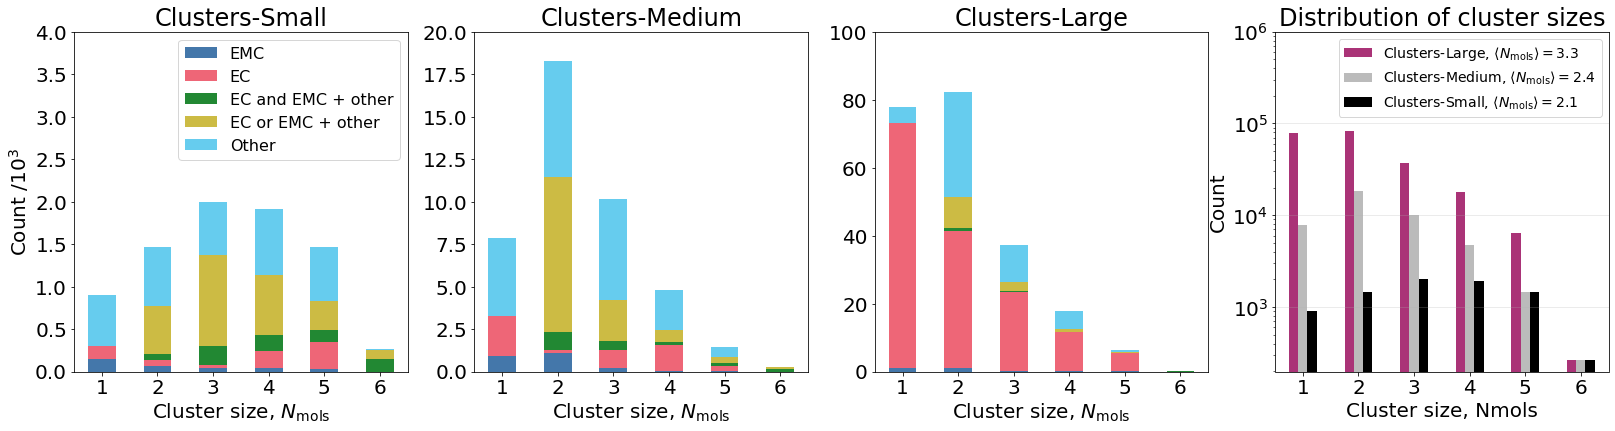

In [102]:
#fsize = 26
#plt.rcParams.update({'font.size': fsize})

fig, axs = plt.subplots(1,4, figsize=(11*scale, 2.5*scale), sharey=False)
comps = {
    'Clusters-Small':clusters_small_1_comp,
    'Clusters-Medium':clusters_medium_1_comp,
    'Clusters-Large':clusters_large_comp,
}

axs = axs.ravel()
for i, (ax, (name, data)) in enumerate(zip(axs, comps.items())):
    d = data/1e3
    if i == 0:
        ax.set_ylim([0,4])
    elif i == 1:
        ax.set_ylim([0,20])
    elif i == 2:
        ax.set_ylim([0,100])

    d.plot.bar(ax=ax, legend=False, stacked=True, rot=0)
    if i == 0: ax.legend(fontsize=fsize-4, ncols=1)
    ax.set_title(name)

    if i == 0: ax.set_ylabel('Count /$10^3$')
    ax.set_xlabel('Cluster size, $N_\\text{mols}$')

axs[-1].set_title('Distribution of cluster sizes')
scaled_stats_df = stats_df
scaled_stats_df[['Clusters-Large', 'Clusters-Medium', 'Clusters-Small']].plot.bar(
    ylabel='Count',
	rot=0,
	ax=axs[-1],
    color=cset[5:],
)
axs[-1].set_yscale('log')
axs[-1].set_ylim([0,1e6])

axs[-1].grid(axis='y', alpha=0.3)
axs[-1].legend(
    [
        f'Clusters-Large, $\\langle N_\\text{{mols}} \\rangle = {clusters_small_avg:.1f}$',
        f'Clusters-Medium, $\\langle N_\\text{{mols}} \\rangle = {clusters_medium_avg:.1f}$',
        f'Clusters-Small, $\\langle N_\\text{{mols}} \\rangle = {clusters_large_avg:.1f}$',
    ],
    fontsize=fsize-6,
)